In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [49]:
import os

print(os.getcwd())

/Users/ehsanalamgir/Desktop/IDS102_A3/Project


In [50]:
import pandas as pd

df = pd.read_csv("/Users/ehsanalamgir/Desktop/IDS102_A3/Project/Dataset.csv")

In [51]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [52]:
df.shape

(5000, 13)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [54]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [55]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [56]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [57]:
df.duplicated().sum()

np.int64(2)

In [58]:
df.nunique()

Age                          7
Gender                       2
Country                    111
Academic_Level               3
Most_Used_Platform          12
Purpose_Of_Use               4
Avg_Daily_Usage_Hours       79
Daily_Unlocks              200
Study_Hours                 76
Physical_Activity_Hours     44
Sleep_Hours_Per_Night       63
Stress_Level                 4
Mental_Health_Score         59
dtype: int64

In [59]:
correlation = df.corr(numeric_only=True)

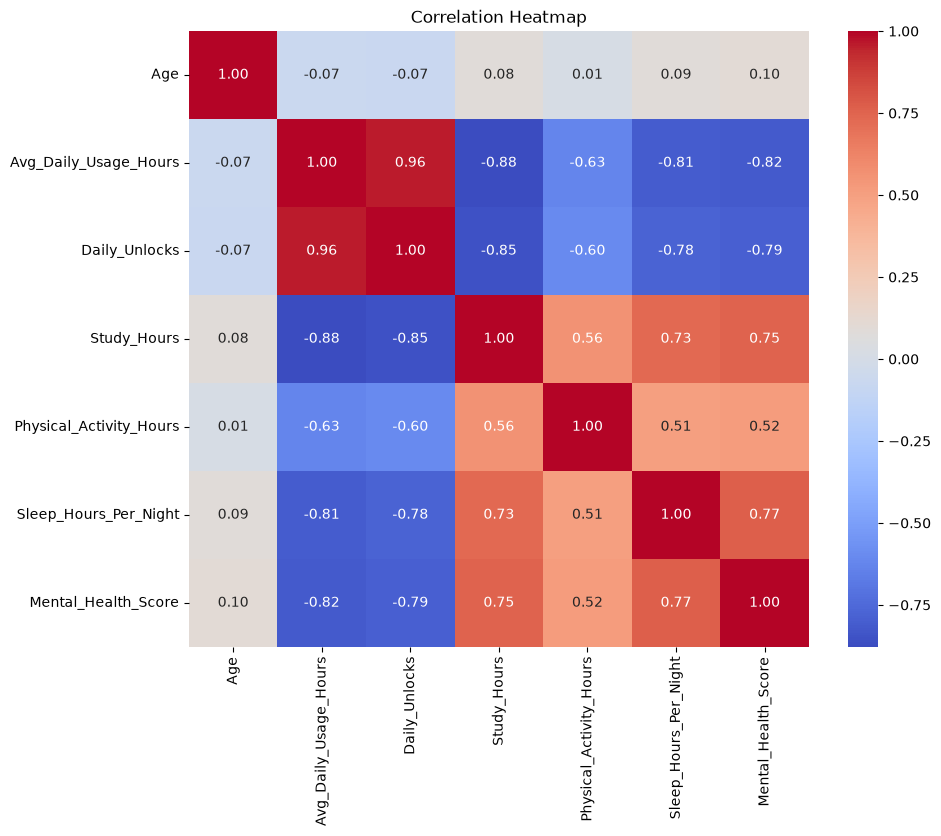

In [60]:


plt.figure(figsize=(10,8))


sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [61]:
df.std(numeric_only=True)

Age                         1.736620
Avg_Daily_Usage_Hours       1.653913
Daily_Unlocks              42.858254
Study_Hours                 1.637018
Physical_Activity_Hours     0.668398
Sleep_Hours_Per_Night       1.221391
Mental_Health_Score         1.278701
dtype: float64

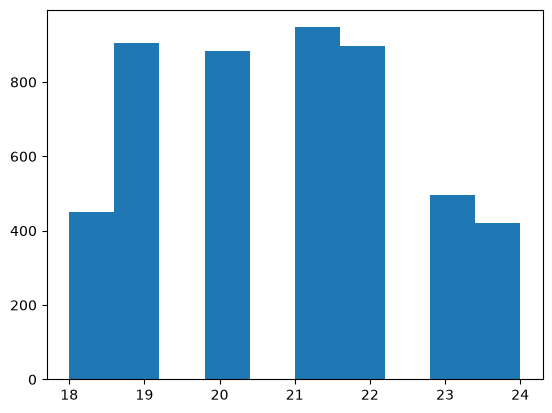

In [62]:
plt.hist(df["Age"])
plt.show()

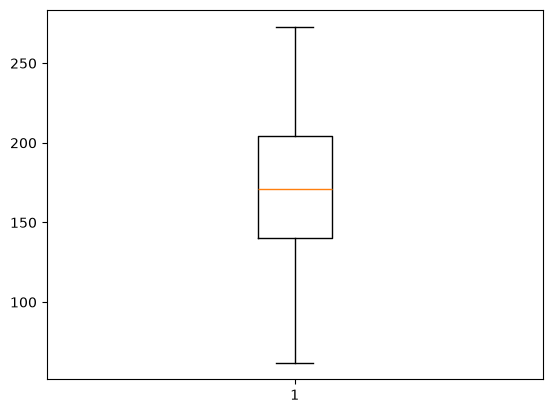

In [63]:
plt.boxplot(df["Daily_Unlocks"])
plt.show()

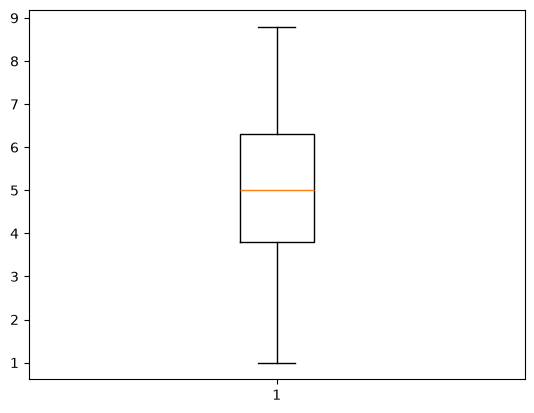

In [64]:
plt.boxplot(df["Avg_Daily_Usage_Hours"])
plt.show()

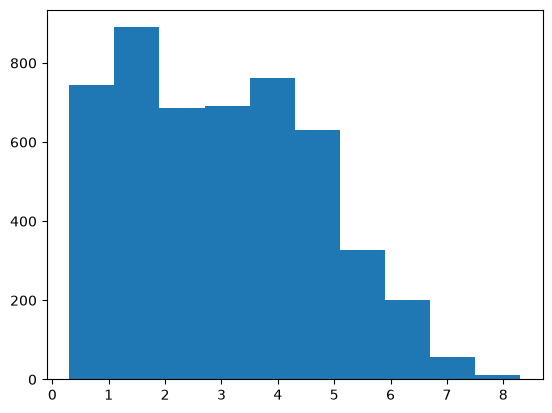

In [65]:
plt.hist(df["Study_Hours"])
plt.show()

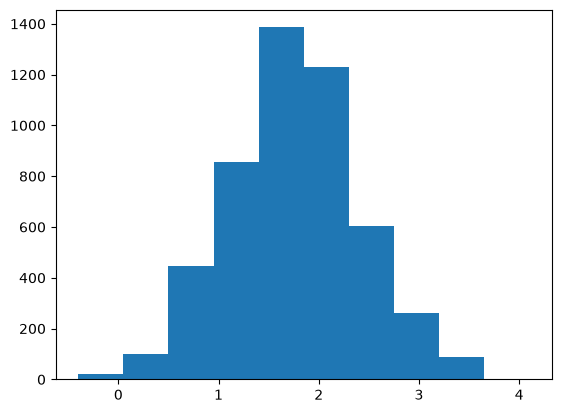

In [66]:
plt.hist(df["Physical_Activity_Hours"])
plt.show()

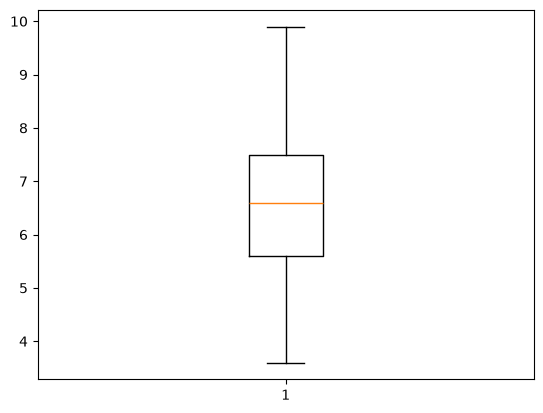

In [67]:
plt.boxplot(df["Sleep_Hours_Per_Night"])
plt.show()

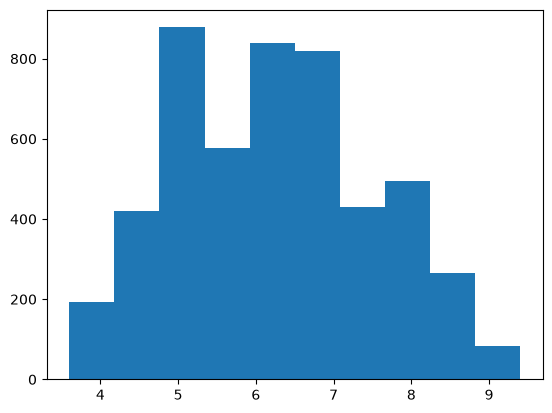

In [68]:
plt.hist(df["Mental_Health_Score"])
plt.show()

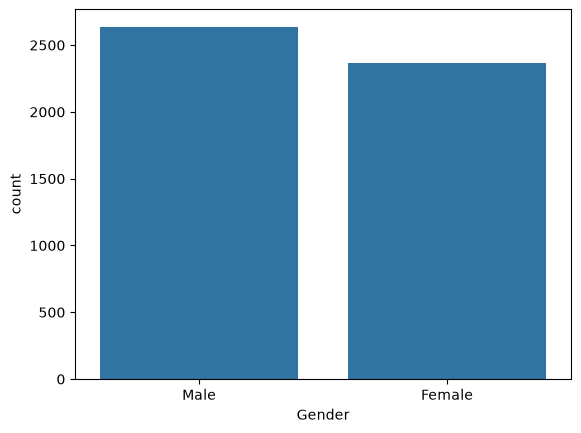

In [69]:
sns.countplot(x="Gender",data=df)
plt.show()

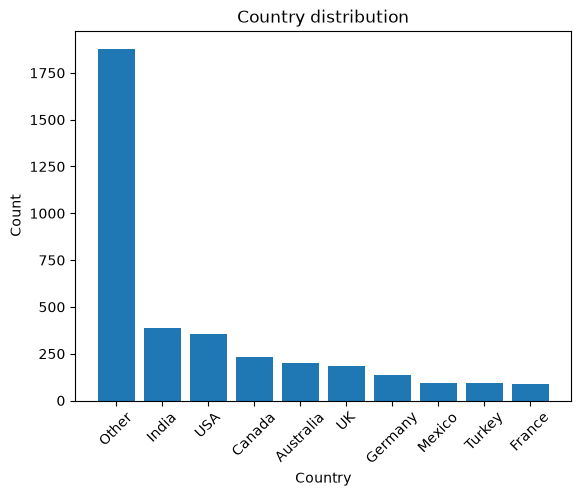

In [70]:
country = df["Country"].value_counts().head(10)
plt.bar(country.index,country.values)
plt.title("Country distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

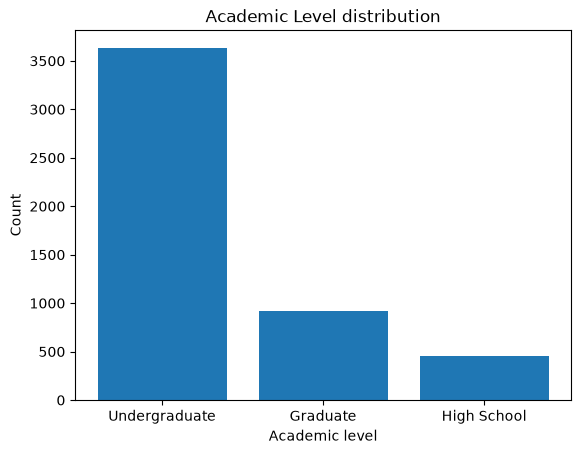

In [71]:
academic =df["Academic_Level"].value_counts()
plt.bar(academic.index,academic.values)
plt.title("Academic Level distribution")
plt.xlabel("Academic level")
plt.ylabel("Count")
plt.show()

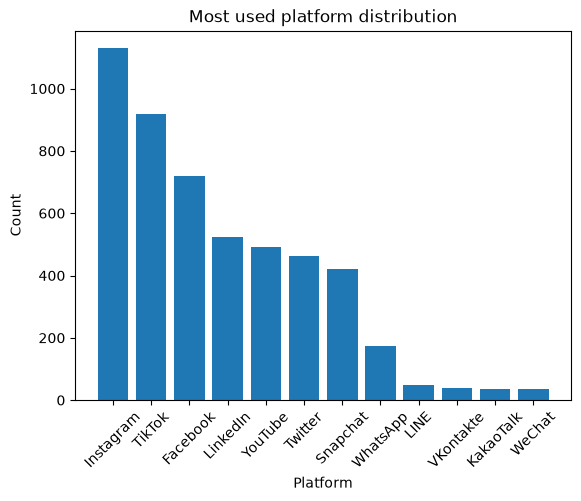

In [72]:
platform = df["Most_Used_Platform"].value_counts()
plt.bar(platform.index,platform.values)
plt.title("Most used platform distribution")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

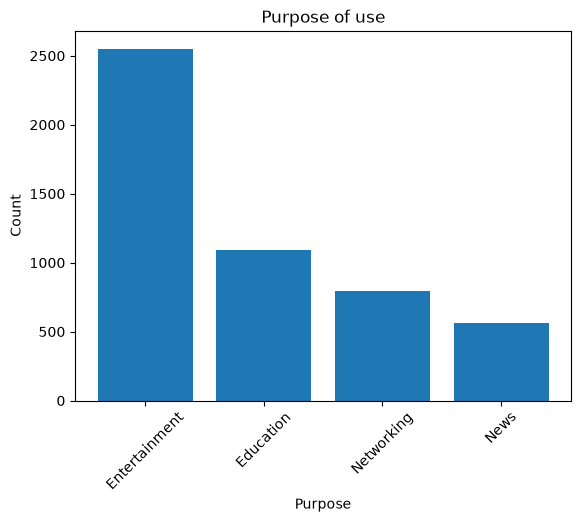

In [73]:
purpose = df["Purpose_Of_Use"].value_counts()
plt.bar(purpose.index, purpose.values)
plt.title("Purpose of use")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Gender', ylabel='Mental_Health_Score'>

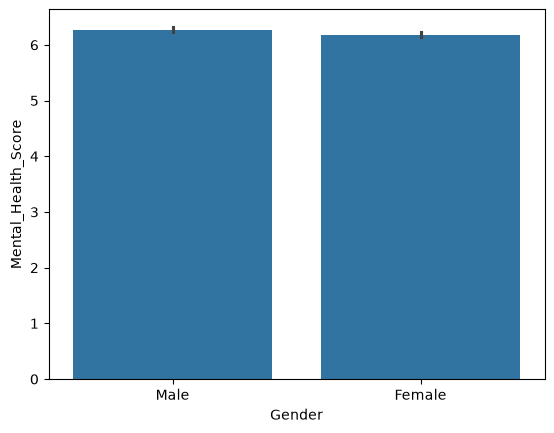

In [74]:
df.groupby("Gender")["Mental_Health_Score"].mean()
sns.barplot(x="Gender", y="Mental_Health_Score", data=df)

<Axes: xlabel='Academic_Level', ylabel='Study_Hours'>

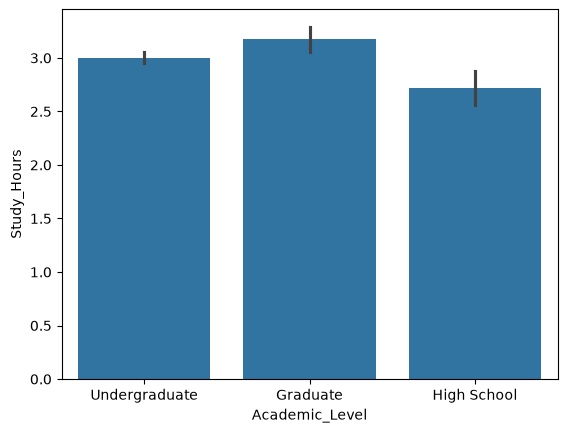

In [75]:
df.groupby("Academic_Level")["Study_Hours"].mean()
sns.barplot(x="Academic_Level", y="Study_Hours", data=df)

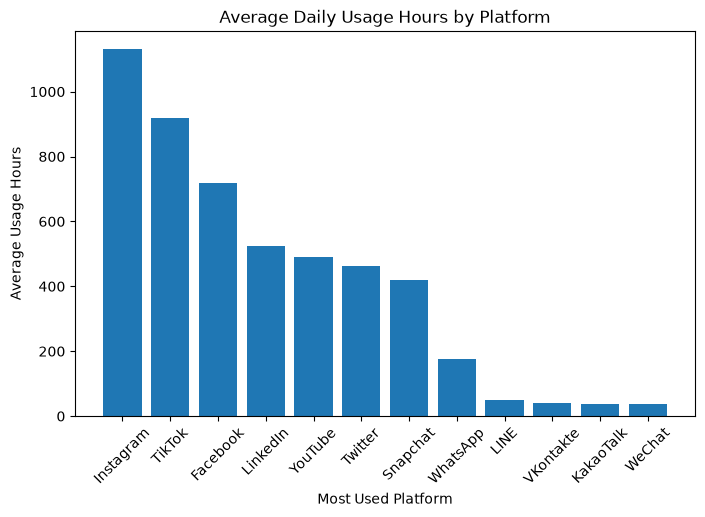

In [76]:
df.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].mean()
plt.figure(figsize=(8,5))
plt.bar(platform.index, platform.values)
plt.title("Average Daily Usage Hours by Platform")
plt.xlabel("Most Used Platform")
plt.ylabel("Average Usage Hours")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

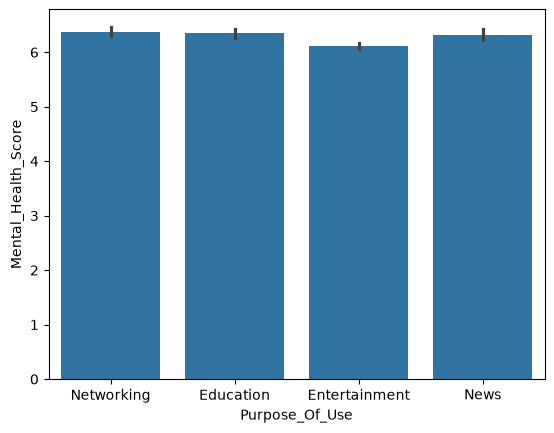

In [77]:
df.groupby("Purpose_Of_Use")["Mental_Health_Score"].mean()
sns.barplot(x="Purpose_Of_Use", y="Mental_Health_Score", data=df)

<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

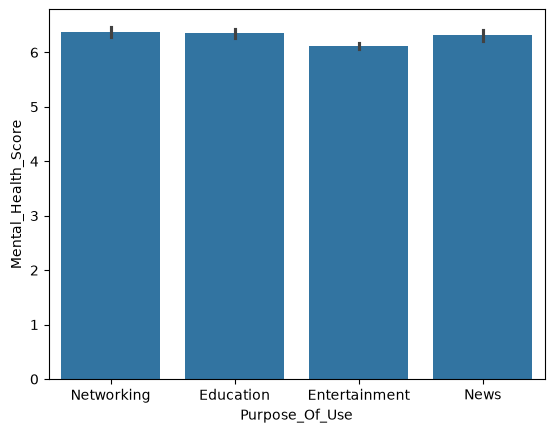

In [78]:
df.groupby("Country")["Mental_Health_Score"].mean()
sns.barplot(x="Purpose_Of_Use", y="Mental_Health_Score", data=df)

In [79]:
label_encoder = LabelEncoder()
catagorical_columns = [
    "Gender",
    "Country",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Stress_Level"
]
for col in catagorical_columns:
    df[col]= label_encoder.fit_transform(df[col])

In [80]:
X= df.drop("Stress_Level",axis=1)
y =df["Stress_Level"]

In [81]:
x_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=43
)

In [82]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(X_test)

In [83]:
print("Decision Tree Accuracy: ") ## stress level prediction
print(accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 
0.755
[[209   2  43  40]
 [  3 101  34   0]
 [ 47  35 169   3]
 [ 36   0   2 276]]
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       294
           1       0.73      0.73      0.73       138
           2       0.68      0.67      0.67       254
           3       0.87      0.88      0.87       314

    accuracy                           0.76      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.76      0.75      1000



In [84]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(X_test)

In [85]:
print("Random Forest Accuracy: ")

print(accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 
0.88
[[260   0  10  24]
 [  0 111  27   0]
 [ 28   9 216   1]
 [ 19   0   2 293]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       294
           1       0.93      0.80      0.86       138
           2       0.85      0.85      0.85       254
           3       0.92      0.93      0.93       314

    accuracy                           0.88      1000
   macro avg       0.89      0.87      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [86]:
lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

y_pred_lr = lr.predict(X_test)

/Users/ehsanalamgir/Desktop/IDS102_A3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [87]:
print("Logistic Regression Accuracy")

print(accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy
0.737
[[198   2  43  51]
 [  0  89  49   0]
 [ 49  31 173   1]
 [ 35   0   2 277]]
              precision    recall  f1-score   support

           0       0.70      0.67      0.69       294
           1       0.73      0.64      0.68       138
           2       0.65      0.68      0.66       254
           3       0.84      0.88      0.86       314

    accuracy                           0.74      1000
   macro avg       0.73      0.72      0.72      1000
weighted avg       0.74      0.74      0.74      1000



In [88]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
6     Avg_Daily_Usage_Hours    0.214149
7             Daily_Unlocks    0.200349
10    Sleep_Hours_Per_Night    0.145195
11      Mental_Health_Score    0.104312
8               Study_Hours    0.099894
9   Physical_Activity_Hours    0.070629
2                   Country    0.049262
0                       Age    0.035257
4        Most_Used_Platform    0.034095
5            Purpose_Of_Use    0.022160
1                    Gender    0.013803
3            Academic_Level    0.010896


In [89]:
X = df.drop("Mental_Health_Score", axis=1)

y = df["Mental_Health_Score"]

In [90]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Country",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Stress_Level"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [92]:
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))

R2 Score: -13.22795967367888
MAE: 4.6338
MSE: 24.673059999999996


In [93]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [94]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

R2 Score: 0.9135530716720155
MAE: 0.28249880000000016
MSE: 0.14990977612888895
